# Fused Softmax
Adopted from https://triton-lang.org/main/getting-started/tutorials/02-fused-softmax.html#sphx-glr-getting-started-tutorials-02-fused-softmax-py

In [1]:
!nvidia-smi

Sat Apr 19 01:59:46 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4090        On  | 00000000:18:00.0 Off |                  Off |
|  0%   38C    P3              46W / 450W |  12398MiB / 24564MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import torch
import triton
import triton.language as tl

In [3]:
DEVICE = 'cuda'

## Naive softmax

In [4]:
def naive_softmax(x):
    """Compute row-wise softmax of X using native pytorch

    We subtract the maximum element in order to avoid overflows. Softmax is invariant to
    this shift.
    """
    # exp(x_i - max)/sum(exp(x - max)) = safesoftmax
    
    # read  MN elements ; write M  elements
    x_max = x.max(dim=1)[0]
    # read MN + M elements ; write MN elements
    z = x - x_max[:, None]
    # read  MN elements ; write MN elements
    numerator = torch.exp(z)
    # read  MN elements ; write M  elements
    denominator = numerator.sum(dim=1)
    # read MN + M elements ; write MN elements
    ret = numerator / denominator[:, None]
    # in total: read 5MN + 2M elements ; wrote 3MN + 2M elements
    return ret

## Test the correctness

In [5]:
def test_softmax(BT, V, f):
    shape = (BT, V)
    x = torch.randn(shape, device=DEVICE)

    output_ref = torch.softmax(x, dim=-1)
    output_triton = f(x)    
    
    print(f"Testing {shape=}")
    torch.testing.assert_close(output_triton, output_ref)
    print("✅ Triton kernel is correct!")

In [6]:
BT = 1024
for V in [2 ** i for i in range(9, 16)]:
    try:
        test_softmax(BT, V, naive_softmax)
    except AssertionError as e:
        print("AssertionError occurred: {e}")

Testing shape=(1024, 512)
✅ Triton kernel is correct!
Testing shape=(1024, 1024)
✅ Triton kernel is correct!
Testing shape=(1024, 2048)
✅ Triton kernel is correct!
Testing shape=(1024, 4096)
✅ Triton kernel is correct!
Testing shape=(1024, 8192)
✅ Triton kernel is correct!
Testing shape=(1024, 16384)
✅ Triton kernel is correct!
Testing shape=(1024, 32768)
✅ Triton kernel is correct!


## Benchmark

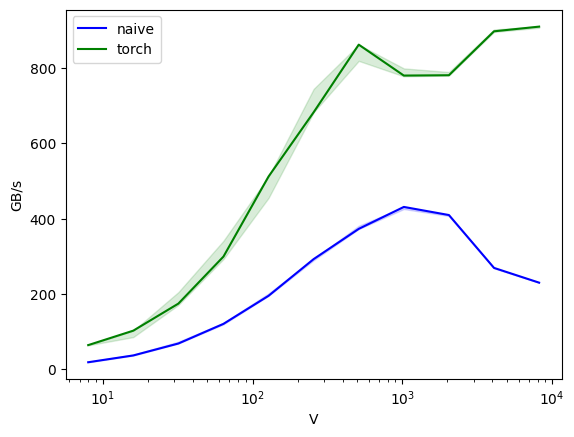

naive-softmax-performance:
         V       naive       torch
0      8.0   18.492099   64.000000
1     16.0   36.571428  102.400003
2     32.0   68.266668  174.297867
3     64.0  120.470586  299.251150
4    128.0  195.047621  512.000001
5    256.0  292.571425  682.666643
6    512.0  372.893315  862.315828
7   1024.0  431.157914  780.190482
8   2048.0  409.600010  781.062210
9   4096.0  269.141677  897.753389
10  8192.0  229.957181  910.222190


<Figure size 640x480 with 0 Axes>

In [7]:
import os

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['V'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(3, 14, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['naive', 'torch'],  # Possible values for `line_arg`.
        line_names=['naive', 'torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='naive-softmax-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(V, provider):
    BT = 4096
    shape = (BT, V)
    x = torch.randn(shape, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1), quantiles=quantiles)
    if provider == 'naive':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: naive_softmax(x), quantiles=quantiles)
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))

## Write Triton kernel

In [8]:
@triton.jit
def softmax_kernel_v0(x_ptr, output_ptr, n_cols, BLOCK_SIZE: tl.constexpr):
    
    pid = tl.program_id(0)
    # x shape (n_rows, n_cols)
    # Calculate the starting pointer of each row
    x_row_start = x_ptr + pid * n_cols
    output_row_start = output_ptr + pid * n_cols

    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_cols

    x_row = tl.load(x_row_start + offsets, mask=mask, other=float('-inf')) # shape: (1, BLOCK_SIZE)
    x_max = tl.max(x_row, axis=0)                                          # shape: (1,)
    numerator = tl.exp(x_row - x_max)                                      # shape: (1, BLOCK_SIZE)
    denominator = tl.sum(numerator, axis=0)                                # shape: (1,)
    
    softmax_output = numerator / denominator                               # shape: (1, BLOCK_SIZE)
 

    tl.store(output_row_start + offsets, softmax_output, mask=mask)

## Helper function to allocate tensors

In [9]:
def triton_softmax_v0(x):
    BT, V = x.shape
    n_rows, n_cols = BT, V
    output = torch.empty_like(x)
    
    MAX_BLOCK_SIZE = 65536 // x.element_size()
    BLOCK_SIZE = min(MAX_BLOCK_SIZE, triton.next_power_of_2(n_cols))

    assert n_cols <= BLOCK_SIZE, f"This implementation does not support more than {BLOCK_SIZE} elements in the last dimension. Got:{n_cols}"

    grid = lambda META: (n_rows,)
    softmax_kernel_v0[grid](x, output, n_cols, BLOCK_SIZE=BLOCK_SIZE)

    return output


## Benchmark with `triton.testing.do_bench`

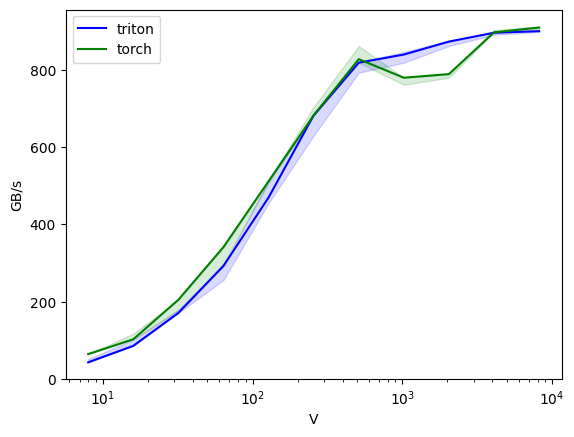

softmax-performance:
         V      triton       torch
0      8.0   42.666665   64.000000
1     16.0   85.333330  102.400003
2     32.0  170.666661  204.800005
3     64.0  292.571425  341.333321
4    128.0  469.792115  512.000001
5    256.0  682.666643  682.666643
6    512.0  819.200021  828.259098
7   1024.0  840.205157  780.190482
8   2048.0  873.813292  789.590371
9   4096.0  896.793673  897.753389
10  8192.0  900.838476  910.222190


<Figure size 640x480 with 0 Axes>

In [10]:
import os

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['V'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(3, 14, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['triton', 'torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='softmax-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(V, provider):
    BT = 4096
    shape = (BT, V)
    x = torch.randn(shape, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_softmax_v0(x), quantiles=quantiles)
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))

## Simple for loop approach


In [11]:
@triton.jit
def for_loop_softmax_kernel(x_ptr, output_ptr, n_cols, BLOCK_SIZE: tl.constexpr):
    
    pid = tl.program_id(0)

    # Calculate the starting pointer of each row
    x_row_start = x_ptr + pid * n_cols
    output_row_start = output_ptr + pid * n_cols


    x_max = float("-inf")

    # First Pass: Find max_x
    for i in tl.range(0, n_cols, BLOCK_SIZE):
        # Chunk in row-wise. Update global maximum each loops
        offsets = i + tl.arange(0, BLOCK_SIZE)
        mask = offsets < n_cols
        x_block = tl.load(x_row_start + offsets, mask=mask, other=float('-inf')) 
        
        block_max = tl.max(x_block, axis=0)  # local maximum
        x_max = tl.maximum(x_max, block_max)         # update global maximum


    # Second Pass: Find denominator sum(exp(x - x_max))
    denominator = 0.0

    for i in tl.range(0, n_cols, BLOCK_SIZE):
        offsets = i + tl.arange(0, BLOCK_SIZE)
        mask = offsets < n_cols
        x_block = tl.load(x_row_start + offsets, mask=mask, other=float('-inf')) 

        numerator = tl.exp(x_block - x_max)
        denominator += tl.sum(numerator)

    # Now we have the correct denominator

    # Final Pass: Calculate output and store

    for i in tl.range(0, n_cols, BLOCK_SIZE):
        offsets = i + tl.arange(0, BLOCK_SIZE)
        mask = offsets < n_cols
        x_block = tl.load(x_row_start + offsets, mask=mask, other=float('-inf')) 

        numerator = tl.exp(x_block - x_max)
        output_block = numerator / denominator

        tl.store(output_row_start + offsets, output_block, mask=mask)




def triton_for_loop_softmax(x):
    BT, V = x.shape
    n_rows, n_cols = BT, V
    output = torch.empty_like(x)
    
    MAX_BLOCK_SIZE = 65536 // x.element_size()
    BLOCK_SIZE = min(MAX_BLOCK_SIZE, triton.next_power_of_2(n_cols))

    grid = lambda META: (n_rows,)
    for_loop_softmax_kernel[grid](x, output, n_cols, BLOCK_SIZE=BLOCK_SIZE)

    return output

In [12]:
BT = 1024
for V in [2 ** i for i in range(9, 16)]:
      test_softmax(BT, V, triton_for_loop_softmax)

Testing shape=(1024, 512)
✅ Triton kernel is correct!
Testing shape=(1024, 1024)
✅ Triton kernel is correct!
Testing shape=(1024, 2048)
✅ Triton kernel is correct!
Testing shape=(1024, 4096)
✅ Triton kernel is correct!
Testing shape=(1024, 8192)
✅ Triton kernel is correct!
Testing shape=(1024, 16384)
✅ Triton kernel is correct!
Testing shape=(1024, 32768)
✅ Triton kernel is correct!


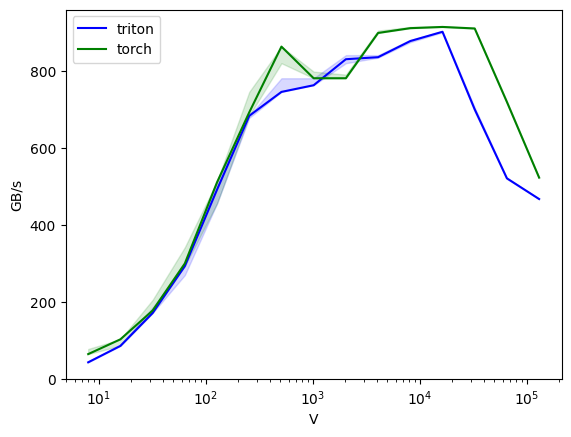

softmax-naive-for-loop-performance:
           V      triton       torch
0        8.0   42.666665   64.000000
1       16.0   85.333330  102.400003
2       32.0  170.666661  177.124327
3       64.0  292.571425  299.251150
4      128.0  490.906375  510.007768
5      256.0  682.666643  691.672815
6      512.0  744.727267  862.315828
7     1024.0  762.046512  780.190482
8     2048.0  829.569645  780.190482
9     4096.0  834.853491  897.753389
10    8192.0  876.735766  910.222190
11   16384.0  900.838476  913.393720
12   32768.0  699.517009  909.432746
13   65536.0  520.320546  718.694972
14  131072.0  466.605704  522.264201


<Figure size 640x480 with 0 Axes>

In [13]:
import os

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['V'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(3, 18, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['triton', 'torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='softmax-naive-for-loop-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(V, provider):
    BT = 4096
    shape = (BT, V)
    x = torch.randn(shape, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_for_loop_softmax(x), quantiles=quantiles)
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))

In [14]:
def calculate_settings(n, element_size):
    # reference: https://github.com/unslothai/unsloth/blob/fd753fed99ed5f10ef8a9b7139588d9de9ddecfb/unsloth/kernels/utils.py#L43

    MAX_BLOCK_SIZE = 65536 // element_size
    BLOCK_SIZE = min(MAX_BLOCK_SIZE, triton.next_power_of_2(n))
    num_warps = 4
    if BLOCK_SIZE >= 32768 // element_size:
        num_warps = 32 
    elif BLOCK_SIZE >= 8192 // element_size:
        num_warps = 16
    elif BLOCK_SIZE >= 2048 // element_size:
        num_warps = 8
    return BLOCK_SIZE, num_warps

In [15]:
def triton_tuned_for_loop_softmax(x):
    BT, V = x.shape
    n_rows, n_cols = BT, V
    output = torch.empty_like(x)
    
    BLOCK_SIZE, num_warps = calculate_settings(n_cols, x.element_size())

    
    grid = lambda META: (n_rows,)
    for_loop_softmax_kernel[grid](x, output, n_cols, BLOCK_SIZE=BLOCK_SIZE, num_warps=num_warps)

    return output

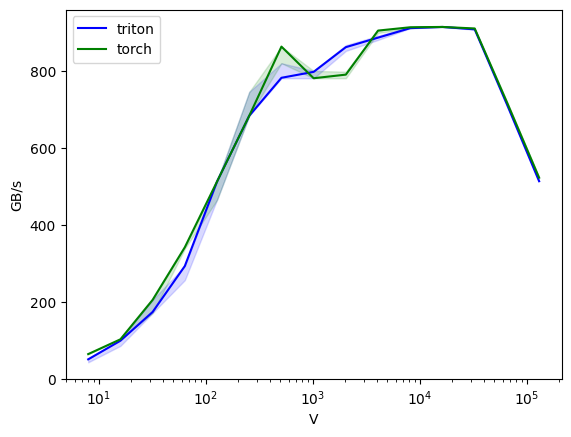

softmax-tuned-for-loop-performance:
           V      triton       torch
0        8.0   50.412308   64.000000
1       16.0   98.698796  102.400003
2       32.0  173.375663  204.800005
3       64.0  292.571425  341.333321
4      128.0  512.000001  512.000001
5      256.0  682.666643  682.666643
6      512.0  781.353219  862.315828
7     1024.0  796.790268  780.190482
8     2048.0  860.899863  789.590371
9     4096.0  885.621583  903.944839
10    8192.0  910.271587  912.549163
11   16384.0  913.393720  913.393720
12   32768.0  907.072700  909.420442
13   65536.0  712.510436  718.202711
14  131072.0  512.876477  522.069195


<Figure size 640x480 with 0 Axes>

In [16]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['V'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(3, 18, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['triton', 'torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='softmax-tuned-for-loop-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(V, provider):
    BT = 4096
    shape = (BT, V)
    x = torch.randn(shape, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_tuned_for_loop_softmax(x), quantiles=quantiles)
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))

## Better Alogrithm : Online Softmax 

https://github.com/NVIDIA/online-softmax

https://arxiv.org/pdf/1805.02867

In [17]:
@triton.jit
def online_softmax_kernel(x_ptr, output_ptr, n_cols, BLOCK_SIZE: tl.constexpr):
    
    pid = tl.program_id(0)

    # Calculate the starting pointer of each row
    x_row_start = x_ptr + pid * n_cols
    output_row_start = output_ptr + pid * n_cols

    # First Pass: Find statistics maximum m and denominator d.
    x_max = float('-inf')
    denominator = 0.0

    for i in tl.range(0, n_cols, BLOCK_SIZE):
        offsets = i + tl.arange(0, BLOCK_SIZE)
        mask = offsets < n_cols
        x_block = tl.load(x_row_start + offsets, mask=mask, other=float('-inf')) 
        block_max = tl.max(x_block)

        new_x_max = tl.maximum(x_max, block_max)
        denominator = denominator * tl.exp(x_max - new_x_max) + tl.sum(tl.exp(x_block - new_x_max))
        x_max = new_x_max


    # Now we have the correct denominator

    # Final Pass: Calculate output and store

    for i in tl.range(0, n_cols, BLOCK_SIZE):
        offsets = i + tl.arange(0, BLOCK_SIZE)
        mask = offsets < n_cols
        x_block = tl.load(x_row_start + offsets, mask=mask, other=float('-inf')) 

        numerator = tl.exp(x_block - x_max)
        output_block = numerator / denominator

        tl.store(output_row_start + offsets, output_block, mask=mask)




def triton_online_softmax(x):
    BT, V = x.shape
    n_rows, n_cols = BT, V
    output = torch.empty_like(x)

    BLOCK_SIZE, num_warps = calculate_settings(n_cols, x.element_size())

    grid = lambda META: (n_rows,)
    online_softmax_kernel[grid](x, output, n_cols, BLOCK_SIZE=BLOCK_SIZE, num_warps=num_warps)

    return output

In [18]:
BT = 1024
for V in [2 ** i for i in range(9, 16)]:
      test_softmax(BT, V, triton_online_softmax)

Testing shape=(1024, 512)
✅ Triton kernel is correct!
Testing shape=(1024, 1024)
✅ Triton kernel is correct!
Testing shape=(1024, 2048)
✅ Triton kernel is correct!
Testing shape=(1024, 4096)
✅ Triton kernel is correct!
Testing shape=(1024, 8192)
✅ Triton kernel is correct!
Testing shape=(1024, 16384)
✅ Triton kernel is correct!
Testing shape=(1024, 32768)
✅ Triton kernel is correct!


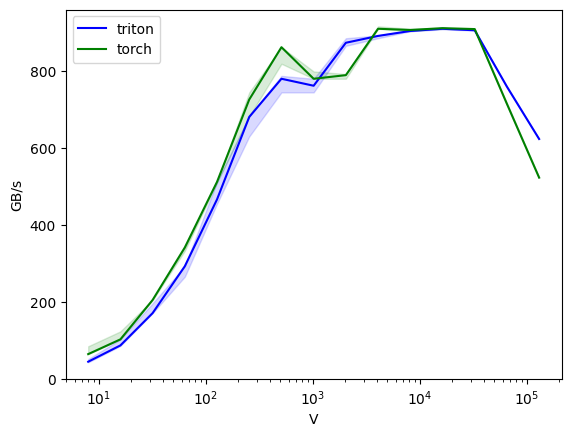

online-softmax-performance:
           V      triton       torch
0        8.0   44.281082   64.000000
1       16.0   86.687831  102.400003
2       32.0  170.666661  204.800005
3       64.0  292.571425  341.333321
4      128.0  466.448422  512.000001
5      256.0  680.893520  726.160639
6      512.0  780.190482  862.315828
7     1024.0  762.046512  780.190482
8     2048.0  873.813292  789.590371
9     4096.0  891.646266  910.222190
10    8192.0  904.432122  907.072700
11   16384.0  910.222190  911.805197
12   32768.0  906.288707  909.432746
13   65536.0  759.700036  715.019439
14  131072.0  623.595600  523.110997


<Figure size 640x480 with 0 Axes>

In [22]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['V'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(3, 18, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['triton', 'torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='online-softmax-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(V, provider):
    BT = 4096
    shape = (BT, V)
    x = torch.randn(shape, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_online_softmax(x), quantiles=quantiles)
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))

## Summary

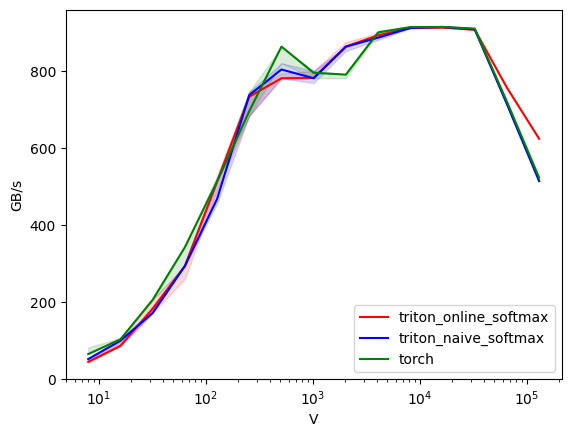

all-softmax-performance:
           V  triton_online_softmax  triton_naive_softmax       torch
0        8.0              43.807487             51.200001   64.000000
1       16.0              85.333330             98.698796  102.400003
2       32.0             182.044442            170.666661  204.800005
3       64.0             292.571425            292.571425  341.333321
4      128.0             512.000001            466.448422  512.000001
5      256.0             732.245830            736.359542  694.421205
6      512.0             780.190482            802.891241  862.315828
7     1024.0             780.771418            780.190482  794.375734
8     2048.0             862.315828            862.315828  789.590371
9     4096.0             891.646266            885.621583  899.100555
10    8192.0             910.419811            910.765763  913.095474
11   16384.0             911.805197            913.393720  913.393720
12   32768.0             906.288707            907.072700  909.18

<Figure size 640x480 with 0 Axes>

In [20]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['V'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(3, 18, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton_online_softmax', 'triton_naive_softmax', 'torch'],  # Possible values for `line_arg`.
        line_names=['triton_online_softmax', 'triton_naive_softmax', 'torch'],  # Label name for the lines.
        styles=[('red', '-'), ('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='all-softmax-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(V, provider):
    BT = 4096
    shape = (BT, V)
    x = torch.randn(shape, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1), quantiles=quantiles)
    if provider == 'triton_online_softmax':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_online_softmax(x), quantiles=quantiles)
    if provider == 'triton_naive_softmax':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_tuned_for_loop_softmax(x), quantiles=quantiles)
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))